In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

plot_binary = True
plot_multiclass = True
plot_resnet = True

run = "run1"

binary_dir = f"/home/paul/Msci/dm_sets/{run}_samples/"
binary_signal_dir = f"/home/paul/Msci/dm_sets/{run}_signal/"

multiclass_dir = f"/home/paul/Msci/dm_sets_multiclass/{run}/"

resnet_dir = "/home/paul/Msci/dm_sets_resnet/"
resnet_models = ["resnet18_gn", "resnet18_bn", "resnet34_gn", "resnet34_bn"]

In [13]:
if plot_binary:
    signal_binary = pd.read_csv(binary_signal_dir + f"{run}_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores.csv")
    nu_binary = pd.read_csv(binary_dir + f"{run}_NuMI_nu_overlay_larcv_cropped_scores.csv")
    dirt_binary = pd.read_csv(binary_dir + f"{run}_NuMI_dirt_larcv_cropped_scores.csv")
    offbeam_binary = pd.read_csv(binary_dir + f"{run}_offbeam_larcv_cropped_full_set_scores.csv")
    print(f"Binary - Signal: {len(signal_binary)}, Nu: {len(nu_binary)}, Dirt: {len(dirt_binary)}, Offbeam: {len(offbeam_binary)}")

if plot_multiclass:
    signal_multi = pd.read_csv(multiclass_dir + f"{run}_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores_multiclass.csv")
    nu_multi = pd.read_csv(multiclass_dir + f"{run}_NuMI_nu_overlay_larcv_cropped_scores_multiclass.csv")
    dirt_multi = pd.read_csv(multiclass_dir + f"{run}_NuMI_dirt_larcv_cropped_scores_multiclass.csv")
    offbeam_multi = pd.read_csv(multiclass_dir + f"{run}_offbeam_larcv_cropped_full_set_scores_multiclass.csv")
    print(f"Multiclass - Signal: {len(signal_multi)}, Nu: {len(nu_multi)}, Dirt: {len(dirt_multi)}, Offbeam: {len(offbeam_multi)}")

resnet_data = {}
if plot_resnet:
    for model in resnet_models:
        samples_path = os.path.join(resnet_dir, f"{run}_samples_{model}")
        signal_path = os.path.join(resnet_dir, f"{run}_signal_{model}")
        
        sig = pd.read_csv(os.path.join(signal_path, f"{run}_dt_ratio_0.6_ma_0.05_pi0_larcv_cropped_scores.csv"))
        nu = pd.read_csv(os.path.join(samples_path, f"{run}_NuMI_nu_overlay_larcv_cropped_scores.csv"))
        dirt = pd.read_csv(os.path.join(samples_path, f"{run}_NuMI_dirt_larcv_cropped_scores.csv"))
        offbeam = pd.read_csv(os.path.join(samples_path, f"{run}_offbeam_larcv_cropped_full_set_scores.csv"))
        
        resnet_data[model] = {"signal": sig, "nu": nu, "dirt": dirt, "offbeam": offbeam}
        print(f"{model} - Signal: {len(sig)}, Nu: {len(nu)}, Dirt: {len(dirt)}, Offbeam: {len(offbeam)}")

Binary - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889
Multiclass - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889
resnet18_gn - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889
resnet18_bn - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889
resnet34_gn - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889
resnet34_bn - Signal: 4219, Nu: 13770, Dirt: 3331, Offbeam: 3889


In [14]:
roc_results = {}

# Binary
if plot_binary:
    bkg_binary = pd.concat([nu_binary, dirt_binary, offbeam_binary], ignore_index=True)
    y_true_binary = np.concatenate([np.ones(len(signal_binary)), np.zeros(len(bkg_binary))])
    y_score_binary = np.concatenate([signal_binary['signal_score'], bkg_binary['signal_score']])
    fpr_binary, tpr_binary, _ = roc_curve(y_true_binary, y_score_binary)
    auc_binary = auc(fpr_binary, tpr_binary)
    roc_results['Binary MPID'] = (fpr_binary, tpr_binary, auc_binary)
    print(f"Binary CNN AUC: {auc_binary:.4f}")

# Multiclass
if plot_multiclass:
    bkg_multi = pd.concat([nu_multi, dirt_multi, offbeam_multi], ignore_index=True)
    y_true_multi = np.concatenate([np.ones(len(signal_multi)), np.zeros(len(bkg_multi))])
    y_score_multi = np.concatenate([signal_multi['p2'], bkg_multi['p2']])
    fpr_multi, tpr_multi, _ = roc_curve(y_true_multi, y_score_multi)
    auc_multi = auc(fpr_multi, tpr_multi)
    roc_results['Multiclass MPID'] = (fpr_multi, tpr_multi, auc_multi)
    print(f"Multiclass CNN AUC: {auc_multi:.4f}")

# ResNet
if plot_resnet:
    for model, data in resnet_data.items():
        bkg = pd.concat([data['nu'], data['dirt'], data['offbeam']], ignore_index=True)
        y_true = np.concatenate([np.ones(len(data['signal'])), np.zeros(len(bkg))])
        y_score = np.concatenate([data['signal']['signal_score'], bkg['signal_score']])
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_val = auc(fpr, tpr)
        
        label = model.replace("_", " ").replace("gn", "GN").replace("bn", "BN").replace("resnet", "ResNet")
        roc_results[label] = (fpr, tpr, auc_val)
        print(f"{label} AUC: {auc_val:.4f}")

Binary CNN AUC: 0.9527
Multiclass CNN AUC: 0.9557
ResNet18 GN AUC: 0.9514
ResNet18 BN AUC: 0.9300
ResNet34 GN AUC: 0.9681
ResNet34 BN AUC: 0.9619


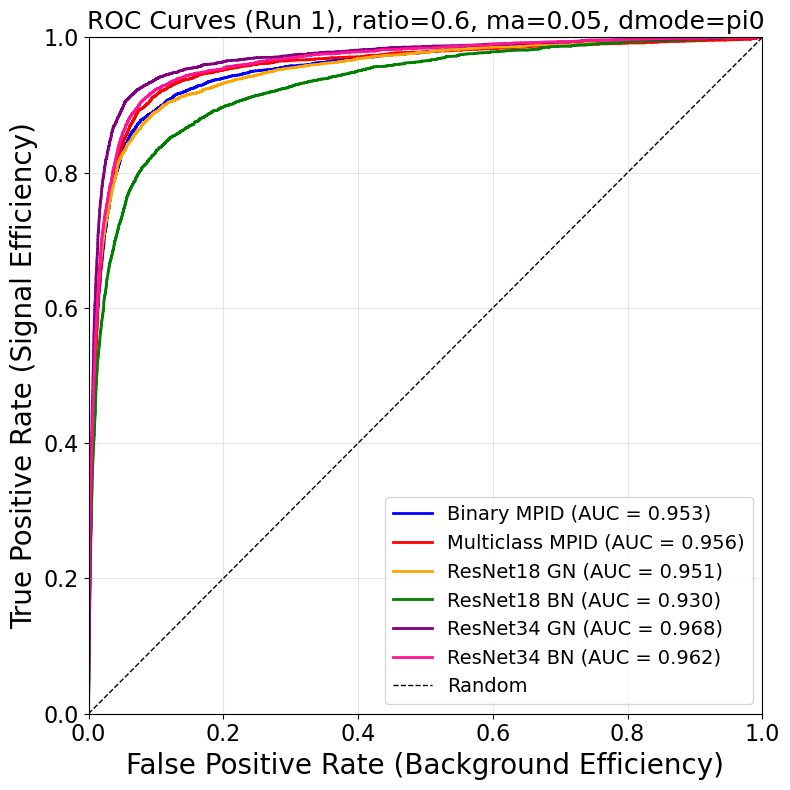

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = {
    'Binary MPID': 'blue',
    'Multiclass MPID': 'red',
    'ResNet18 GN': 'orange',
    'ResNet18 BN': 'green',
    'ResNet34 GN': 'purple',
    'ResNet34 BN': 'deeppink',
}

for label, (fpr, tpr, auc_val) in roc_results.items():
    color = colors.get(label, 'gray')
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=20)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=20)
ax.set_title(f'ROC Curves ({run.replace("run", "Run ")}), ratio=0.6, ma=0.05, dmode=pi0', fontsize=18)
ax.legend(loc='lower right', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'/home/paul/Msci/plots/inference/ROC_curves/roc_all_models_{run}.png', dpi=300)
plt.show()

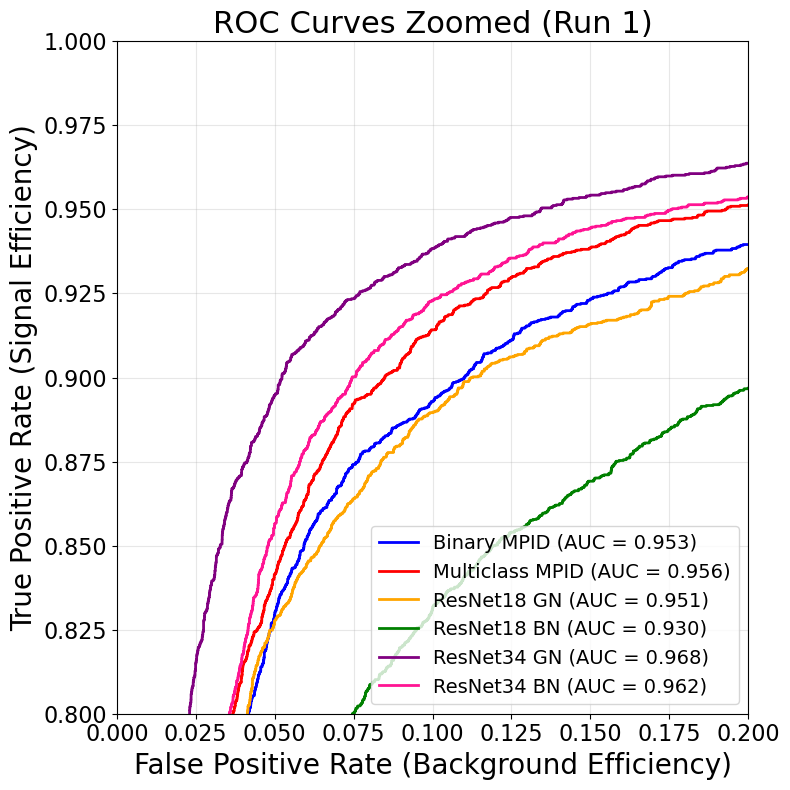

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

for label, (fpr, tpr, auc_val) in roc_results.items():
    color = colors.get(label, 'gray')
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc_val:.3f})')

ax.set_xlabel('False Positive Rate (Background Efficiency)', fontsize=20)
ax.set_ylabel('True Positive Rate (Signal Efficiency)', fontsize=20)
ax.set_title(f'ROC Curves Zoomed ({run.replace("run", "Run ")})', fontsize=22)
ax.legend(loc='lower right', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xlim([0, 0.2])
ax.set_ylim([0.8, 1.0])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'/home/paul/Msci/plots/inference/ROC_curves/roc_all_models_{run}_zoomed.png', dpi=300)
plt.show()